<a href="https://colab.research.google.com/github/Vasugi2003/WEB-SERVER-LOG-ANALYSIS-USING-PYSPARK/blob/main/Spark_Web_server_log_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for spark: filename=spark-0.2.1-py3-none-any.whl size=58748 sha256=f9f2557ac019eeffef2baac04686c9626b001a82bf1e2ee3736f13a718e5a0a9
  Stored in directory: /root/.cache/pip/wheels/63/88/77/b4131110ea4094540f7b47c6d62a649807d7e94800da5eab0b
Successfully built spark


In [2]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.2-py2.py3-none-any.whl size=317812365 sha256=2d971cf3fd2cdd7d543533b9cf01ad6cc91471530f70ebba9d7779b8c5077dbf
  Stored in directory: /root/.cache/pip/wheels/34/34/bd/03944534c44b677cd5859f248090daa9fb27b3c8f8e5f49574
Successfully built pyspark


In [3]:
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext

# Configuring Spark
conf = SparkConf().setAppName("Spark-Logs-Handling").setMaster("local[*]")
sc = SparkContext.getOrCreate(conf)

# Creating SQLContext
sqlcontext = SQLContext(sc)

# Reading the log files
rdd = sc.textFile("/content/access_log_Aug95")

# Counting the number of lines
rdd_count = rdd.count()

# Output the count
rdd_count


/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


1569898

In [4]:
i=0
for line in rdd.sample(withReplacement = False, fraction = 0.00001, seed = 100).collect():
    i=i+1
    print(line)
    if i >5:
      break

ix-stp-fl2-19.ix.netcom.com - - [03/Aug/1995:23:03:09 -0400] "GET /images/faq.gif HTTP/1.0" 200 263
slip183-1.kw.jp.ibm.net - - [04/Aug/1995:18:42:17 -0400] "GET /shuttle/missions/sts-70/images/DSC-95EC-0001.gif HTTP/1.0" 200 107133
piweba4y.prodigy.com - - [05/Aug/1995:19:17:41 -0400] "GET /icons/menu.xbm HTTP/1.0" 200 527
ruperts.bt-sys.bt.co.uk - - [07/Aug/1995:04:44:10 -0400] "GET /shuttle/countdown/video/livevideo2.gif HTTP/1.0" 200 69067
dal06-04.ppp.iadfw.net - - [07/Aug/1995:21:10:19 -0400] "GET /images/NASA-logosmall.gif HTTP/1.0" 200 786
ndobson.gsfc.nasa.gov - - [09/Aug/1995:07:29:02 -0400] "GET /images/flight-deck.gif HTTP/1.0" 200 204800


In [5]:
import re

rslt = (rdd.map(lambda line: re.search(r'\S+', line)
   .group(0))
   .take(3))  # Get the IP address / host name
rslt


['in24.inetnebr.com', 'uplherc.upl.com', 'uplherc.upl.com']

In [6]:
rslt=(rdd.map(lambda line: re.search('\S+',line)
   .group(0))
   .take(3)) # Get the IP address \host name
rslt

['in24.inetnebr.com', 'uplherc.upl.com', 'uplherc.upl.com']

In [7]:
rslt = (rdd.map(lambda line: re.search('(\S+ -\d{4})', line)
    .groups())
    .take(3))  # Get the date
rslt


[('[01/Aug/1995:00:00:01 -0400',),
 ('[01/Aug/1995:00:00:07 -0400',),
 ('[01/Aug/1995:00:00:08 -0400',)]

In [8]:
rslt=(rdd.map(lambda line: re.search('"\w+\s+([^\s]+)\s+HTTP.*"',line)
    .groups())
    .take(3)) # Get the REST call
rslt

[('/shuttle/missions/sts-68/news/sts-68-mcc-05.txt',),
 ('/',),
 ('/images/ksclogo-medium.gif',)]

In [9]:
rslt=(rdd.map(lambda line: re.search('"\s(\d{3})',line)
    .groups())
    .take(5)) #Get the status
rslt

[('200',), ('304',), ('304',), ('304',), ('304',)]

In [10]:
rslt=(rdd.map(lambda line: re.search('^.*\s(\d*)$',line)
    .groups())
    .take(3)) # Get the content size
rslt

[('1839',), ('0',), ('0',)]

In [11]:
rslt=(rdd.map(lambda line: re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3}\s(\d*)$)',line)
    .groups())
    .take(3))
rslt

[('in24.inetnebr.com',
  ' -',
  ' ',
  '-',
  '[01/Aug/1995:00:00:01 -0400]',
  '"GET /shuttle/missions/sts-68/news/sts-68-mcc-05.txt HTTP/1.0"',
  '/shuttle/missions/sts-68/news/sts-68-mcc-05.txt',
  '200 1839',
  '1839'),
 ('uplherc.upl.com',
  ' -',
  ' ',
  '-',
  '[01/Aug/1995:00:00:07 -0400]',
  '"GET / HTTP/1.0"',
  '/',
  '304 0',
  '0'),
 ('uplherc.upl.com',
  ' -',
  ' ',
  '-',
  '[01/Aug/1995:00:00:08 -0400]',
  '"GET /images/ksclogo-medium.gif HTTP/1.0"',
  '/images/ksclogo-medium.gif',
  '304 0',
  '0')]

In [12]:
def parse_log1(line):
    match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3}\s(\d*)$)',line)
    if match is None:
        return(line,0)
    else:
        return(line,1)

In [13]:
n_logs = rdd.count()
failed = rdd.map(lambda line: parse_log1(line)).filter(lambda line: line[1] == 0).count()
print('Out of a total of {} logs, {} failed to parse'.format(n_logs,failed))
# Get the failed records line[1] == 0
failed1=rdd.map(lambda line: parse_log1(line)).filter(lambda line: line[1]==0)
failed1.take(3)

Out of a total of 1569898 logs, 15987 failed to parse


[('gw1.att.com - - [01/Aug/1995:00:03:53 -0400] "GET /shuttle/missions/sts-73/news HTTP/1.0" 302 -',
  0),
 ('js002.cc.utsunomiya-u.ac.jp - - [01/Aug/1995:00:07:33 -0400] "GET /shuttle/resources/orbiters/discovery.gif HTTP/1.0" 404 -',
  0),
 ('pipe1.nyc.pipeline.com - - [01/Aug/1995:00:12:37 -0400] "GET /history/apollo/apollo-13/apollo-13-patch-small.gif" 200 12859',
  0)]

In [14]:
import re
def parse_failed(line):
    match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3}\s-$)',line)
    if match is None:
        return(line,0)
    else:
        return(line,1)

In [15]:
failed2=rdd.map(lambda line: parse_failed(line)).filter(lambda line: line[1]==1)
failed2.take(5)

[('gw1.att.com - - [01/Aug/1995:00:03:53 -0400] "GET /shuttle/missions/sts-73/news HTTP/1.0" 302 -',
  1),
 ('js002.cc.utsunomiya-u.ac.jp - - [01/Aug/1995:00:07:33 -0400] "GET /shuttle/resources/orbiters/discovery.gif HTTP/1.0" 404 -',
  1),
 ('tia1.eskimo.com - - [01/Aug/1995:00:28:41 -0400] "GET /pub/winvn/release.txt HTTP/1.0" 404 -',
  1),
 ('itws.info.eng.niigata-u.ac.jp - - [01/Aug/1995:00:38:01 -0400] "GET /ksc.html/facts/about_ksc.html HTTP/1.0" 403 -',
  1),
 ('grimnet23.idirect.com - - [01/Aug/1995:00:50:12 -0400] "GET /www/software/winvn/winvn.html HTTP/1.0" 404 -',
  1)]

In [16]:
def parse_log2(line):
    # Parse logs with the rule below
    match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3})\s(\d*)$',line)
    # If match failed then use the rule below
    if match is None:
        match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3}\s-$)',line)
    if match is None:
        return (line, 0) # Return 0 for failure
    else:
        return (line, 1) # Return 1 for success

In [17]:
def map2groups(line):
    match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3})\s(\d*)$',line)
    if match is None:
        match = re.search('^(\S+)((\s)(-))+\s(\[\S+ -\d{4}\])\s("\w+\s+([^\s]+)\s+HTTP.*")\s(\d{3})\s(-)$',line)
    return(match.groups())

In [18]:
parsed_rdd = rdd.map(lambda line: parse_log2(line)).filter(lambda line: line[1] == 1).map(lambda line : line[0])
parsed_rdd2 = parsed_rdd.map(lambda line: map2groups(line))

In [19]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_extract

# Create a Spark session
spark = SparkSession.builder.appName("LogFileAnalysis").getOrCreate()

# Set the correct file path to your logs
logs_file_path = "/content/access_log_Aug95"

# Create a DataFrame by reading the logs file
base_df = spark.read.text(logs_file_path)

# Extract fields using regular expressions
split_df = base_df.select(
    regexp_extract('value', r'^([^\s]+\s)', 1).alias('host'),
    regexp_extract('value', r'^.*\[(\d\d\/\w{3}\/\d{4}:\d{2}:\d{2}:\d{2} -\d{4})]', 1).alias('timestamp'),
    regexp_extract('value', r'^.*"\w+\s+([^\s]+)\s+HTTP.*"', 1).alias('path'),
    regexp_extract('value', r'^.*"\s+([^\s]+)', 1).cast('integer').alias('status'),
    regexp_extract('value', r'^.*\s+(\d+)$', 1).cast('integer').alias('content_size')
)

# Show the resulting DataFrame
split_df.show(5, truncate=False)


+------------------+--------------------------+-----------------------------------------------+------+------------+
|host              |timestamp                 |path                                           |status|content_size|
+------------------+--------------------------+-----------------------------------------------+------+------------+
|in24.inetnebr.com |01/Aug/1995:00:00:01 -0400|/shuttle/missions/sts-68/news/sts-68-mcc-05.txt|200   |1839        |
|uplherc.upl.com   |01/Aug/1995:00:00:07 -0400|/                                              |304   |0           |
|uplherc.upl.com   |01/Aug/1995:00:00:08 -0400|/images/ksclogo-medium.gif                     |304   |0           |
|uplherc.upl.com   |01/Aug/1995:00:00:08 -0400|/images/MOSAIC-logosmall.gif                   |304   |0           |
|uplherc.upl.com   |01/Aug/1995:00:00:08 -0400|/images/USA-logosmall.gif                      |304   |0           |
+------------------+--------------------------+-------------------------

In [20]:
bad_rows_df = split_df.filter(split_df['host'].isNull() |
                              split_df['timestamp'].isNull() |
                              split_df['path'].isNull() |
                              split_df['status'].isNull() |
                             split_df['content_size'].isNull())
bad_rows_df.count()

14178

In [21]:
bad_content_size_df = base_df.filter(~ base_df['value'].rlike(r'\d+$'))
bad_content_size_df.count()

14178

In [22]:
from pyspark.sql.functions import lit, concat
bad_content_size_df.select(concat(bad_content_size_df['value'], lit('*'))).show(4,truncate=False)


+----------------------------------------------------------------------------------------------------------------------------+
|concat(value, *)                                                                                                            |
+----------------------------------------------------------------------------------------------------------------------------+
|gw1.att.com - - [01/Aug/1995:00:03:53 -0400] "GET /shuttle/missions/sts-73/news HTTP/1.0" 302 -*                            |
|js002.cc.utsunomiya-u.ac.jp - - [01/Aug/1995:00:07:33 -0400] "GET /shuttle/resources/orbiters/discovery.gif HTTP/1.0" 404 -*|
|tia1.eskimo.com - - [01/Aug/1995:00:28:41 -0400] "GET /pub/winvn/release.txt HTTP/1.0" 404 -*                               |
|itws.info.eng.niigata-u.ac.jp - - [01/Aug/1995:00:38:01 -0400] "GET /ksc.html/facts/about_ksc.html HTTP/1.0" 403 -*         |
+--------------------------------------------------------------------------------------------------------------

In [23]:
from pyspark.sql.functions import lit, concat
bad_content_size_df.select(concat(bad_content_size_df['value'], lit('*'))).show(4,truncate=False)

+----------------------------------------------------------------------------------------------------------------------------+
|concat(value, *)                                                                                                            |
+----------------------------------------------------------------------------------------------------------------------------+
|gw1.att.com - - [01/Aug/1995:00:03:53 -0400] "GET /shuttle/missions/sts-73/news HTTP/1.0" 302 -*                            |
|js002.cc.utsunomiya-u.ac.jp - - [01/Aug/1995:00:07:33 -0400] "GET /shuttle/resources/orbiters/discovery.gif HTTP/1.0" 404 -*|
|tia1.eskimo.com - - [01/Aug/1995:00:28:41 -0400] "GET /pub/winvn/release.txt HTTP/1.0" 404 -*                               |
|itws.info.eng.niigata-u.ac.jp - - [01/Aug/1995:00:38:01 -0400] "GET /ksc.html/facts/about_ksc.html HTTP/1.0" 403 -*         |
+--------------------------------------------------------------------------------------------------------------

In [24]:
cleaned_df = split_df.na.fill({'content_size': 0})

In [25]:
df= (cleaned_df
     .groupBy('host')
     .count()
     .orderBy('count',ascending=False))
df.show(5)

+--------------------+-----+
|                host|count|
+--------------------+-----+
| edams.ksc.nasa.gov | 6530|
|piweba4y.prodigy....| 4846|
|       163.206.89.4 | 4791|
|piweba5y.prodigy....| 4607|
|piweba3y.prodigy....| 4416|
+--------------------+-----+
only showing top 5 rows



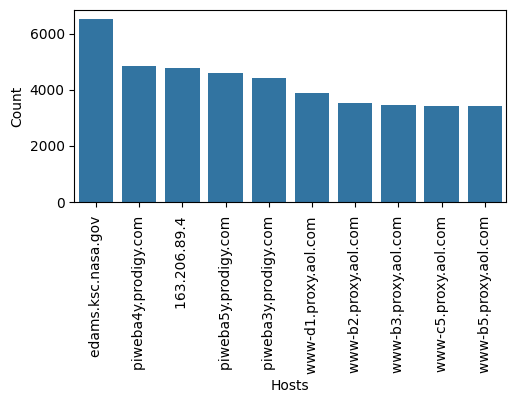

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df1=df.toPandas()
df2 = df1.head(10)
df2.count()
sns.barplot(x='host',y='count',data=df2)
plt.subplots_adjust(bottom=0.5, right=0.8, top=0.9)
plt.xlabel("Hosts")
plt.ylabel('Count')
plt.xticks(rotation="vertical",fontsize=10)
display()

In [27]:
df= (cleaned_df
     .groupBy('path')
     .count()
     .orderBy('count',ascending=False))
df.show(5)

+--------------------+-----+
|                path|count|
+--------------------+-----+
|/images/NASA-logo...|97275|
|/images/KSC-logos...|75283|
|/images/MOSAIC-lo...|67356|
|/images/USA-logos...|66975|
|/images/WORLD-log...|66351|
+--------------------+-----+
only showing top 5 rows



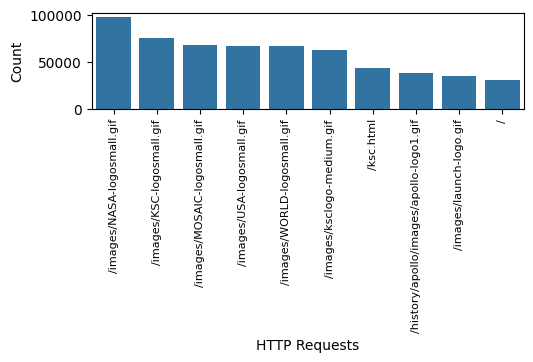

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df1=df.toPandas()
df2 = df1.head(10)
df2.count()
sns.barplot(x='path',y='count',data=df2)
plt.subplots_adjust(bottom=0.7, right=0.8, top=0.9)
plt.xlabel("HTTP Requests")
plt.ylabel('Count')
plt.xticks(rotation=90,fontsize=8)
display()

In [29]:
status_count=(cleaned_df
                .groupBy('status')
                .count()
                .orderBy('count',ascending=False))
status_count.show()

+------+-------+
|status|  count|
+------+-------+
|   200|1398988|
|   304| 134146|
|   302|  26497|
|   404|  10056|
|   403|    171|
|   501|     27|
|   400|     10|
|   500|      3|
+------+-------+



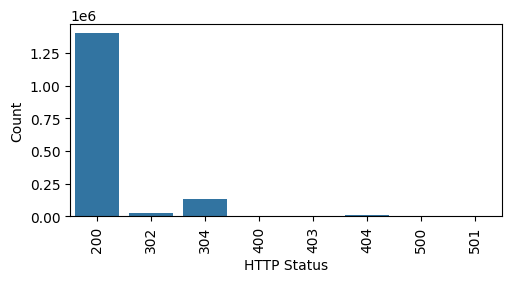

In [30]:

df1=status_count.toPandas()
df2 = df1.head(10)
df2.count()
sns.barplot(x='status',y='count',data=df2)
plt.subplots_adjust(bottom=0.5, right=0.8, top=0.9)
plt.xlabel("HTTP Status")
plt.ylabel('Count')
plt.xticks(rotation="vertical",fontsize=10)
display()


In [31]:
size_counts=(cleaned_df
                .groupBy('content_size')
                .count()
                .orderBy('count',ascending=False))
size_counts.show(10)


+------------+------+
|content_size| count|
+------------+------+
|           0|154588|
|         786| 77836|
|        1204| 63754|
|         363| 58392|
|         234| 58056|
|         669| 57641|
|        5866| 54656|
|        1173| 34396|
|        1713| 30824|
|        7131| 29104|
+------------+------+
only showing top 10 rows



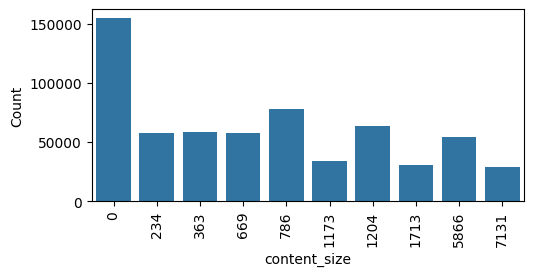

In [32]:
df1=size_counts.toPandas()
df2 = df1.head(10)
df2.count()
sns.barplot(x='content_size',y='count',data=df2)
plt.subplots_adjust(bottom=0.5, right=0.8, top=0.9)
plt.xlabel("content_size")
plt.ylabel('Count')
plt.xticks(rotation="vertical",fontsize=10)
display()